# Step 1: Select Features and Target

In [1]:
import pandas as pd

master_df = pd.read_csv(
    '../data/processed/stock_features.csv'
)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company,MA_7,MA_21,MA_50,Lag_1,Lag_5,Lag_10,Rolling_Mean_7,Rolling_Mean_21,Rolling_Std_7,Rolling_Std_21,Target
0,2019-03-13,596.365295,601.986747,587.866665,591.806143,24577591,Reliance,570.531032,554.009042,537.147859,589.305237,559.847534,540.128174,570.531032,554.009042,17.588990,16.027564,593.820007
1,2019-03-14,593.820007,602.871947,591.407614,597.449648,22753310,Reliance,577.101031,555.870228,539.100331,596.365295,562.260071,541.566711,577.101031,555.870228,16.233306,18.233619,585.011658
2,2019-03-15,585.011658,601.455609,580.386082,595.347211,34764353,Reliance,580.695905,557.245571,541.005887,593.820007,560.865723,544.908630,580.695905,557.245571,14.465790,19.311564,597.582458
3,2019-03-18,597.582458,601.079311,588.264944,589.150193,22104063,Reliance,585.741961,559.898234,543.283698,585.011658,577.243347,542.695374,585.741961,559.898234,13.054957,20.858833,609.312439
4,2019-03-19,609.312439,610.839524,594.506199,601.986734,21448030,Reliance,592.662920,562.682640,545.743878,597.582458,589.305237,547.830017,592.662920,562.682640,10.198316,23.343861,608.825378


In [2]:
feature_cols = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'MA_7',
    'MA_21',
    'MA_50',
    'Lag_1',
    'Lag_5',
    'Lag_10',
    'Rolling_Mean_7',
    'Rolling_Mean_21',
    'Rolling_Std_7',
    'Rolling_Std_21'
]

X = master_df[feature_cols]

y = master_df['Target']

In [3]:
master_df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Company', 'MA_7',
       'MA_21', 'MA_50', 'Lag_1', 'Lag_5', 'Lag_10', 'Rolling_Mean_7',
       'Rolling_Mean_21', 'Rolling_Std_7', 'Rolling_Std_21', 'Target'],
      dtype='object')

# Step 2: Split Data into Training and Testing Sets

In [4]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8059, 15)
Testing data: (2015, 15)


In [5]:
print("Train Start:", X_train.index.min())
print("Train End:", X_train.index.max())

print("Test Start:", X_test.index.min())
print("Test End:", X_test.index.max())

Train Start: 0
Train End: 8058
Test Start: 8059
Test End: 10073


In [6]:
print(master_df.iloc[0]['Date'])
print(master_df.iloc[split_index]['Date'])
print(master_df.iloc[-1]['Date'])

2019-03-13
2024-08-23
2025-12-29


# Step 3:Linear Regression

1.Train Model

In [7]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


2.Make Predictions

In [8]:
y_pred = lr.predict(X_test)

y_pred[:5]

array([12193.20401369, 12129.10199478, 12384.83453168, 12236.84444923,
       12338.59114214])

3.Evaluate Model

In [9]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)

MAE : 25.108378595078452
RMSE: 68.88655991452652
R² : 0.9997877583665554
Intercept: 0.03205036468102662
Coefficients: [-1.23013752e-01 -3.97837810e-02  3.37597573e-02  1.04223816e+00
 -1.96801461e-09 -4.43342057e-02  3.61706268e-02 -1.28751965e-02
  9.57651993e-02  4.37842523e-02 -2.22737130e-02 -4.43342057e-02
  3.61706268e-02  1.49596020e-03  7.77479129e-03]


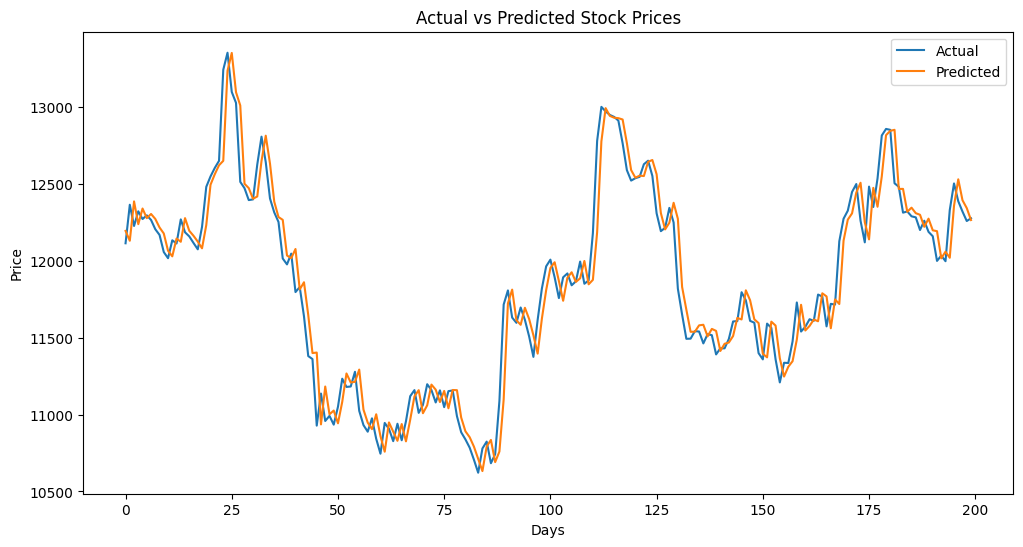

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    y_pred[:200],
    label='Predicted'
)

plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

plt.show()

# Step 4:-Random Forest Regressor

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [12]:
rf_pred = rf.predict(X_test)

rf_pred[:5]

array([12262.34237305, 12196.78150391, 12330.07137695, 12291.93547852,
       12349.58517578])

In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² :", rf_r2)

MAE : 182.3921940418177
RMSE: 705.2254227742137
R² : 0.9777557634678812


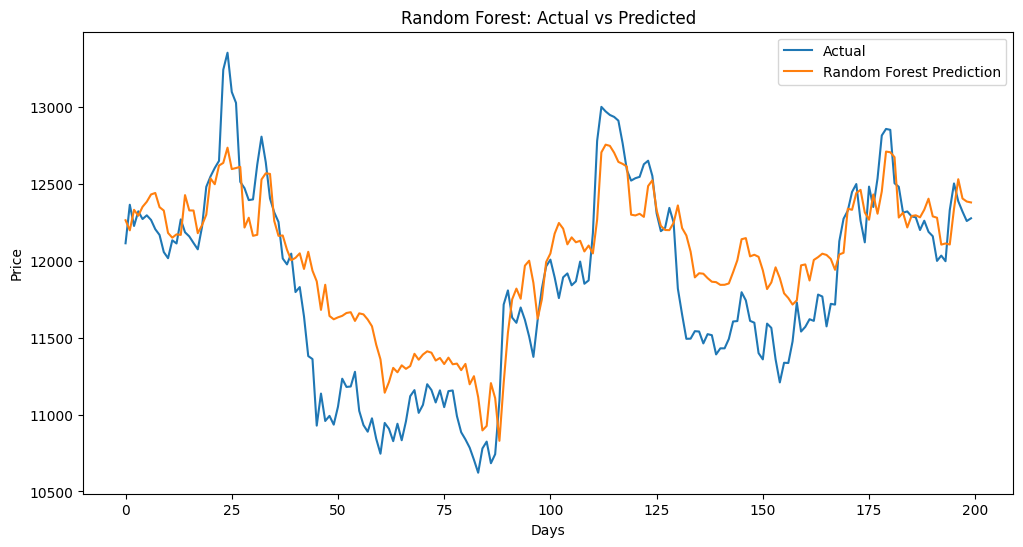

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    rf_pred[:200],
    label='Random Forest Prediction'
)

plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

plt.show()

In [15]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
3,Close,0.859425
1,High,0.065369
2,Low,0.030516
5,MA_7,0.019206
8,Lag_1,0.010290
12,Rolling_Mean_21,0.009204
0,Open,0.003791
11,Rolling_Mean_7,0.000918
7,MA_50,0.000632
6,MA_21,0.000326


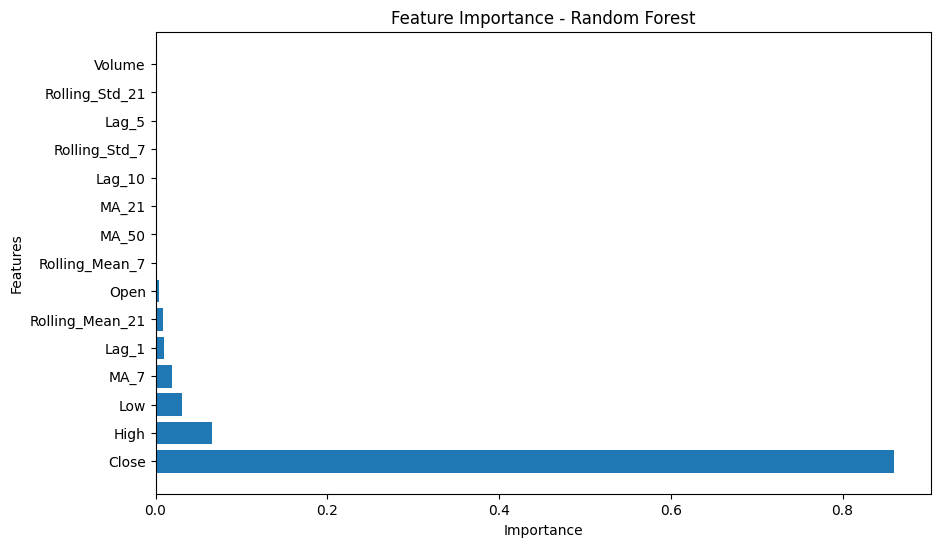

In [16]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')

plt.show()

# Step 5:xgBoost Regressor

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [18]:
xgb_pred = xgb.predict(X_test)

xgb_pred[:5]

array([12175.414, 12251.349, 12268.232, 12400.235, 12382.606],
      dtype=float32)

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = mean_squared_error(
    y_test,
    xgb_pred
) ** 0.5

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R² :", xgb_r2)

MAE : 188.54443580494922
RMSE: 741.2703374033736
R² : 0.9754237945849732


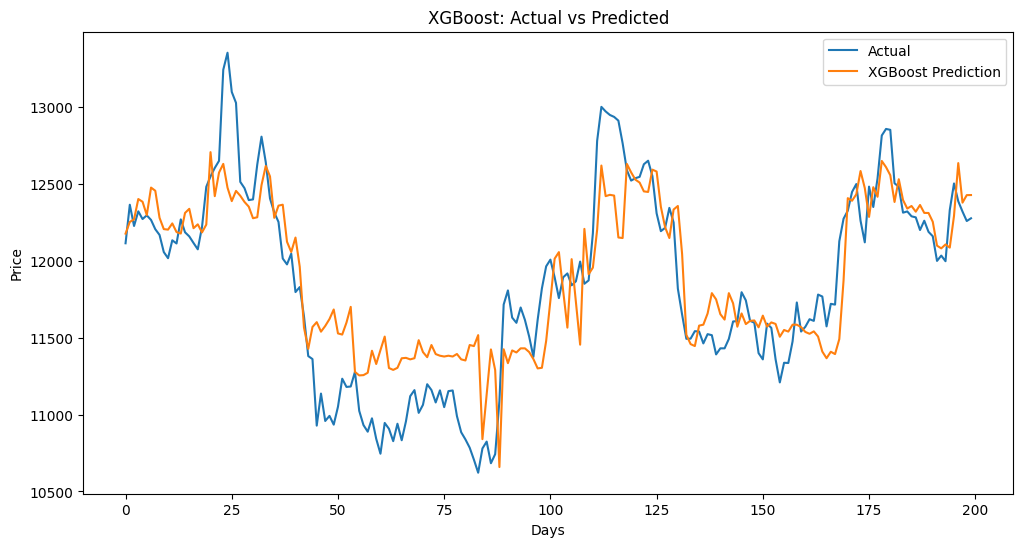

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    xgb_pred[:200],
    label='XGBoost Prediction'
)

plt.title('XGBoost: Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

plt.show()

In [21]:
importance_df_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance_df_xgb = importance_df_xgb.sort_values(
    by='Importance',
    ascending=False
)

importance_df_xgb

,Feature,Importance
8,Lag_1,0.461132
3,Close,0.362964
5,MA_7,0.123417
6,MA_21,0.018494
1,High,0.014713
2,Low,0.009868
0,Open,0.003828
7,MA_50,0.002944
13,Rolling_Std_7,0.001509
9,Lag_5,0.000945


# Step 6-Model Comparision

In [22]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        mae,
        rf_mae,
        xgb_mae
    ],
    'RMSE': [
        rmse,
        rf_rmse,
        xgb_rmse
    ],
    'R2': [
        r2,
        rf_r2,
        xgb_r2
    ]
})

comparison.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear Regression,25.108379,68.886560,0.999788
1,Random Forest,182.392194,705.225423,0.977756
2,XGBoost,188.544436,741.270337,0.975424


Best Model:Linear Regression

In [23]:
print(X.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'MA_7', 'MA_21', 'MA_50',
       'Lag_1', 'Lag_5', 'Lag_10', 'Rolling_Mean_7', 'Rolling_Mean_21',
       'Rolling_Std_7', 'Rolling_Std_21'],
      dtype='object')


In [24]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

feature_importance

,Feature,Coefficient
3,Close,1.042238e+00
0,Open,-1.230138e-01
8,Lag_1,9.576520e-02
11,Rolling_Mean_7,-4.433421e-02
5,MA_7,-4.433421e-02
9,Lag_5,4.378425e-02
1,High,-3.978378e-02
12,Rolling_Mean_21,3.617063e-02
6,MA_21,3.617063e-02
2,Low,3.375976e-02


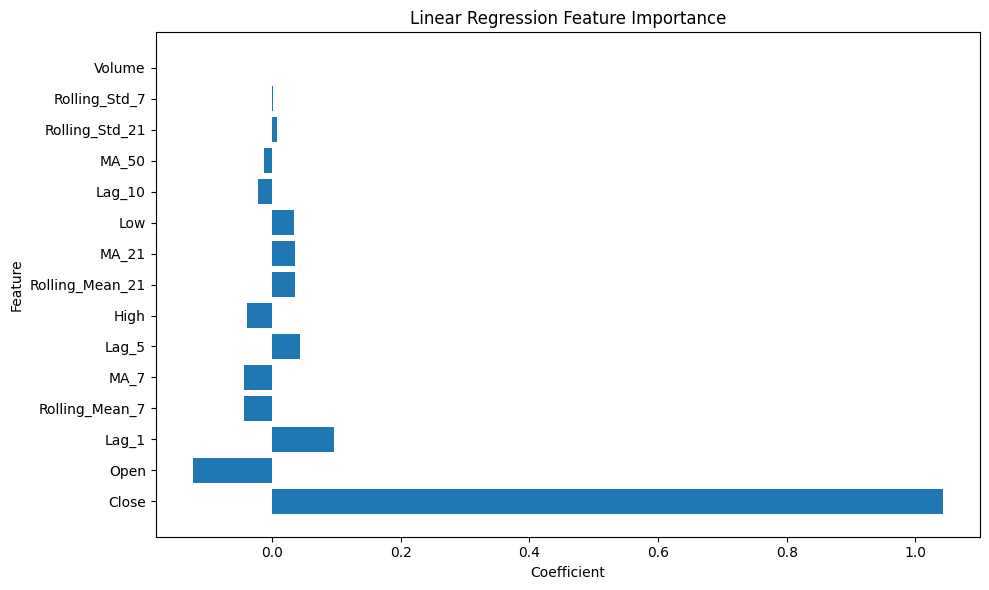

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Coefficient']
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [26]:
import os

print(os.getcwd())

C:\Users\USER\Documents\PROJECTS\stock risk dashboard\notebooks


In [27]:
print(os.listdir(".."))

['dashboard', 'data', 'notebooks', 'outputs', 'src']


In [28]:
import joblib

joblib.dump(
    lr,
    "../outputs/models/best_stock_prediction_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
